# §4.6 — VTI-Reverse Counterfactual Stim Reproduction

This notebook reproduces the §4.6 finding: **a small pixel-space perturbation along `v_L10` flips Qwen2.5-VL from "the circle stays static" to "the circle falls"; matched-magnitude random-direction perturbations do not**.

What runs:

1. **Setup** — load Qwen2.5-VL + the M5a `v_L10` unit direction.
2. **Differentiability smoke** — verify gradients flow from `<h_L10, v_L10>` back to `pixel_values`.
3. **Single-seed gradient ascent** — bounded ε = 0.05 on one baseline circle stim, plot the projection trajectory + show the synthesized image.
4. **Inference comparison** — Qwen2.5-VL response on baseline vs synthesized image; PMR scoring.
5. **Random-direction control** — same procedure with a random unit direction.

Full sweep (5 seeds × 7 configs) lives in `scripts/sec4_6_counterfactual_stim.py`. This notebook is the lightweight 1-seed version meant to run cell-by-cell on a single GPU.

Deep dive: `docs/insights/sec4_6_counterfactual_stim.md`. Spec: `docs/superpowers/specs/2026-04-26-sec4_6-counterfactual-stim-design.md`.

## 0. Setup

Launch from inside the project venv:

```bash
uv run jupyter lab notebooks/sec4_6_counterfactual_stim.ipynb
```

In [1]:
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT / "src"))

import numpy as np
import torch
import matplotlib.pyplot as plt
from PIL import Image
from transformers import AutoModelForImageTextToText, AutoProcessor

print(f"PyTorch : {torch.__version__}")
print(f"CUDA OK : {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU     : {torch.cuda.get_device_name(0)}")
print(f"PROJECT_ROOT: {PROJECT_ROOT}")

PyTorch : 2.11.0+cu130
CUDA OK : True
GPU     : NVIDIA H200
PROJECT_ROOT: /mnt/ddn/prod-runs/thyun.park/src/physical_mode_activation


In [2]:
MODEL_ID = "Qwen/Qwen2.5-VL-7B-Instruct"
DEVICE = "cuda:0"
PROMPT = "What will happen to the circle in the next moment? Answer in one short sentence."

print(f"Loading {MODEL_ID}...")
processor = AutoProcessor.from_pretrained(MODEL_ID)
model = AutoModelForImageTextToText.from_pretrained(
    MODEL_ID, torch_dtype=torch.bfloat16, device_map=DEVICE,
)
model.eval()
print("Loaded.")

Loading Qwen/Qwen2.5-VL-7B-Instruct...


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!


Loading weights:   0%|          | 0/729 [00:00<?, ?it/s]

Loaded.


In [3]:
# Load the M5a v_L10 unit direction.
STEERING_NPZ = PROJECT_ROOT / "outputs/mvp_full_20260424-094103_8ae1fa3d/probing_steering/steering_vectors.npz"
v_L10 = np.load(STEERING_NPZ)["v_unit_10"]
print(f"v_L10 shape: {v_L10.shape}, norm: {np.linalg.norm(v_L10):.6f}")

v_L10 shape: (3584,), norm: 1.000000


Baseline: line_blank_none_fall_000.png


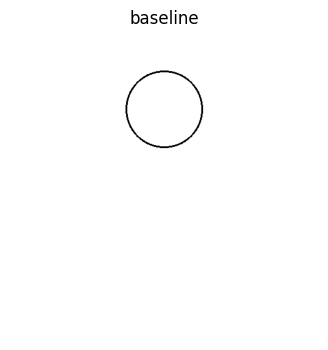

In [4]:
# Pick one baseline circle stim from the M2 stim dir.
BASELINE_DIR = PROJECT_ROOT / "inputs/mvp_full_20260424-093926_e9d79da3/images"
baselines = sorted(BASELINE_DIR.glob("line_blank_none_fall_*.png"))
baseline_path = baselines[0]
print(f"Baseline: {baseline_path.name}")
baseline_pil = Image.open(baseline_path).convert("RGB")
plt.figure(figsize=(4, 4)); plt.imshow(baseline_pil); plt.axis("off"); plt.title("baseline"); plt.show()

## 1. Differentiability smoke

Confirm that `<mean(h_L10[visual]), v_L10>` is differentiable back to `pixel_values`. The gradient should be finite and non-NaN.

In [5]:
from physical_mode.synthesis.counterfactual import (
    prepare_inputs_for_grad, forward_get_layer_hidden,
)

v = torch.from_numpy(v_L10).to(device=model.device, dtype=torch.float32)

inputs, pv_leaf = prepare_inputs_for_grad(model, processor, baseline_pil, PROMPT)
h_visual = forward_get_layer_hidden(model, inputs, layer=10)
h_mean = h_visual.mean(dim=0).to(torch.float32)
projection = (h_mean * v).sum()
projection.backward()

print(f"pixel_values shape : {tuple(pv_leaf.shape)}")
print(f"n_visual tokens    : {h_visual.shape[0]}")
print(f"baseline projection: {float(projection.detach().item()):.4f}")
print(f"grad max_abs       : {pv_leaf.grad.abs().max().item():.4f}")
print(f"grad has NaN       : {torch.isnan(pv_leaf.grad).any().item()}")

pixel_values shape : (1296, 1176)
n_visual tokens    : 324
baseline projection: -2.3573
grad max_abs       : 13.8750
grad has NaN       : False


## 2. Bounded gradient ascent (ε = 0.05) along v_L10

In [6]:
from physical_mode.synthesis.counterfactual import gradient_ascent, pixel_values_from_pil, reconstruct_pil

out_v = gradient_ascent(
    model, processor, baseline_pil, v_L10,
    layer=10, n_steps=200, lr=1e-2,
    eps=0.05, mode="bounded", prompt=PROMPT, log_every=20,
)
print(f"baseline projection: {out_v['baseline_projection']:.4f}")
print(f"final projection   : {out_v['final_projection']:.4f}")

baseline projection: -2.3573
final projection   : 44.5084


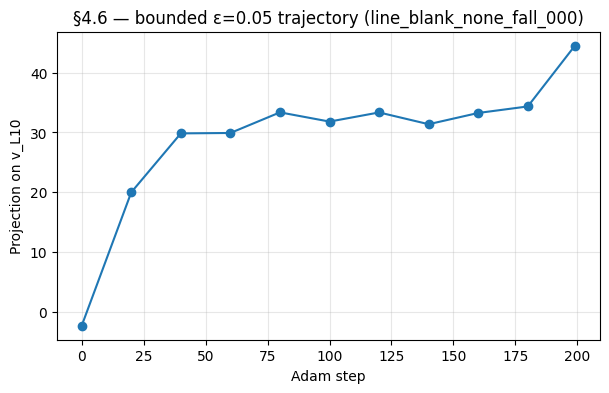

In [7]:
traj = np.array(out_v["projection_trajectory"])
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(traj[:, 0], traj[:, 1], marker="o", linewidth=1.5)
ax.set_xlabel("Adam step"); ax.set_ylabel("Projection on v_L10")
ax.set_title(f"§4.6 — bounded ε=0.05 trajectory ({baseline_path.stem})")
ax.grid(alpha=0.3); plt.show()

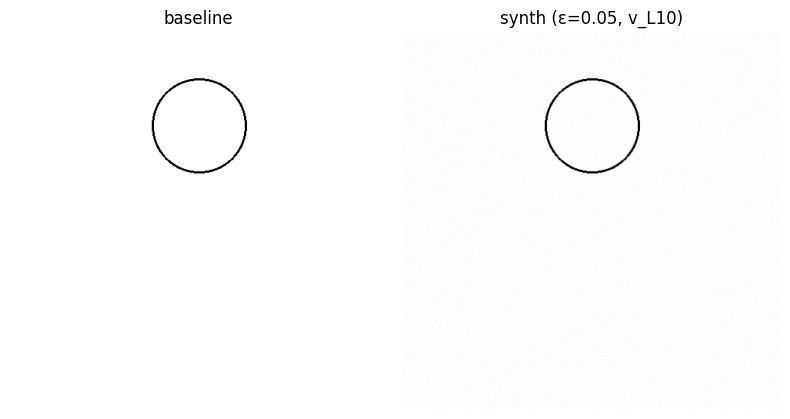

In [8]:
# Reconstruct the synthesized image.
_, grid_thw = pixel_values_from_pil(baseline_pil, processor, PROMPT)
synth_v = reconstruct_pil(out_v["pixel_values_final"], grid_thw, processor)

fig, axes = plt.subplots(1, 2, figsize=(8, 4.2))
axes[0].imshow(baseline_pil); axes[0].set_title("baseline"); axes[0].axis("off")
axes[1].imshow(synth_v); axes[1].set_title("synth (ε=0.05, v_L10)"); axes[1].axis("off")
plt.tight_layout(); plt.show()

## 3. Inference + PMR scoring

In [9]:
from physical_mode.metrics.pmr import score_pmr

def generate(pil):
    msgs = [{"role": "user", "content": [{"type": "image"}, {"type": "text", "text": PROMPT}]}]
    text = processor.apply_chat_template(msgs, tokenize=False, add_generation_prompt=True)
    inputs = processor(images=[pil], text=[text], return_tensors="pt")
    inputs = {k: v.to(model.device) for k, v in inputs.items()}
    with torch.inference_mode():
        out = model.generate(**inputs, max_new_tokens=64, do_sample=False)
    gen = out[:, inputs["input_ids"].shape[1]:]
    return processor.tokenizer.batch_decode(gen, skip_special_tokens=True)[0].strip()

baseline_resp = generate(baseline_pil)
synth_resp_v = generate(synth_v)
print(f"BASELINE    PMR={score_pmr(baseline_resp)}: {baseline_resp}")
print(f"SYNTH v_L10 PMR={score_pmr(synth_resp_v)}: {synth_resp_v}")

[transformers] The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.


BASELINE    PMR=0: The circle will remain unchanged as it is a static image.
SYNTH v_L10 PMR=1: The circle will continue to fall due to gravity.


## 4. Random-direction control

In [10]:
rng = np.random.default_rng(42)
v_random = rng.standard_normal(v_L10.shape).astype(np.float32)
v_random /= np.linalg.norm(v_random) + 1e-8

out_r = gradient_ascent(
    model, processor, baseline_pil, v_random,
    layer=10, n_steps=200, lr=1e-2,
    eps=0.1, mode="bounded", prompt=PROMPT, log_every=20,
)
print(f"random-dir baseline projection: {out_r['baseline_projection']:.4f}")
print(f"random-dir final projection   : {out_r['final_projection']:.4f}")

synth_r = reconstruct_pil(out_r["pixel_values_final"], grid_thw, processor)
synth_resp_r = generate(synth_r)
print(f"SYNTH random PMR={score_pmr(synth_resp_r)}: {synth_resp_r}")

random-dir baseline projection: -1.8753
random-dir final projection   : 99.6288


SYNTH random PMR=0: The circle will remain stationary as there is no indication of movement or change in its position.


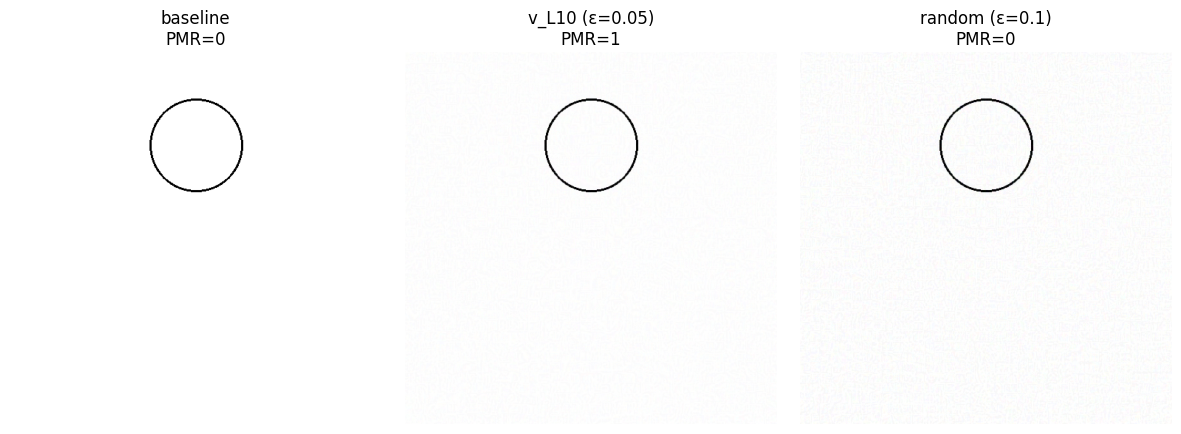

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4.2))
axes[0].imshow(baseline_pil); axes[0].set_title(f"baseline\nPMR={score_pmr(baseline_resp)}"); axes[0].axis("off")
axes[1].imshow(synth_v);     axes[1].set_title(f"v_L10 (ε=0.05)\nPMR={score_pmr(synth_resp_v)}"); axes[1].axis("off")
axes[2].imshow(synth_r);     axes[2].set_title(f"random (ε=0.1)\nPMR={score_pmr(synth_resp_r)}"); axes[2].axis("off")
plt.tight_layout(); plt.show()

## Expected outcome

- Baseline PMR = 0 ("The circle will remain unchanged…")
- Synth (v_L10, ε = 0.05) PMR = 1 ("The circle will continue to fall downward due to gravity.")
- Synth (random, ε = 0.1) PMR = 0 ("The circle will remain stationary as there is no indication of movement…")

The full 5-seed × 7-config sweep (35 runs × 200 steps) is in `scripts/sec4_6_counterfactual_stim.py`. Aggregated result: 5/5 v_L10 flips at ε = 0.05; 0/15 random flips at matched ε = 0.1. See `docs/insights/sec4_6_counterfactual_stim.md` for the full PMR table, mechanism discussion, and scorer-fix note.